In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sehaj1104/student-placement-prediction-dataset-2026/student_placement_prediction_dataset_2026.csv


Dataset Link :- https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026/data

In [2]:
data = pd.read_csv("/kaggle/input/datasets/sehaj1104/student-placement-prediction-dataset-2026/student_placement_prediction_dataset_2026.csv")

# 1. Data understanding

In [3]:
df = pd.DataFrame(data)
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
df.shape

(100000, 26)

In [5]:
print('Columns contains Null values : ')
df.isnull().sum()[df.isnull().sum() > 0]

Columns contains Null values : 


Series([], dtype: int64)

In [6]:
print("Total Duplicates : ",df.duplicated().sum())

Total Duplicates :  0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,100000.0,50000.500000,28867.657797,1.0,25000.750000,50000.500000,75000.250000,100000.00
age,100000.0,21.005740,1.999562,18.0,19.000000,21.000000,23.000000,24.00
cgpa,100000.0,7.496890,0.992834,4.5,6.820000,7.500000,8.180000,10.00
internships_count,100000.0,1.502230,1.225280,0.0,1.000000,1.000000,2.000000,8.00
projects_count,100000.0,3.001860,1.731764,0.0,2.000000,3.000000,4.000000,13.00
certifications_count,100000.0,2.005150,1.416553,0.0,1.000000,2.000000,3.000000,11.00
coding_skill_score,100000.0,69.825326,14.694618,20.0,59.807945,70.006250,80.058762,100.00
aptitude_score,100000.0,64.988108,14.844093,20.0,54.894600,65.011394,75.079266,100.00
communication_skill_score,100000.0,67.960744,13.846636,20.0,58.587535,67.973221,77.503749,100.00
logical_reasoning_score,100000.0,65.931696,14.826790,20.0,55.940547,66.003829,76.113705,100.00


In [9]:
spelling_check = ['gender','branch','college_tier','volunteer_experience','placement_status']
for col in spelling_check:
    print(f"Column Name {col} : ")
    print(df[col].unique())
    print("Total Unique values contains are : ",df[col].nunique())
    print()

Column Name gender : 
['Male' 'Female']
Total Unique values contains are :  2

Column Name branch : 
['IT' 'CSE' 'EEE' 'Civil' 'Mechanical' 'ECE']
Total Unique values contains are :  6

Column Name college_tier : 
['Tier 2' 'Tier 1' 'Tier 3']
Total Unique values contains are :  3

Column Name volunteer_experience : 
['Yes' 'No']
Total Unique values contains are :  2

Column Name placement_status : 
['Not Placed' 'Placed']
Total Unique values contains are :  2



The above confirms that there are no spelling or capitalization inconsistencies in the data (e.g., "Male" appearing as "male" or "mAle" in other rows).

# 2. Data Cleaning

## 2.1 Removing redundant Column

In [10]:
df = df.drop(columns = ['student_id'],axis=1)
df.head(2)

,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.0
1,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.0


## 2.2 Renaming Columns

In [11]:
df = df.rename(columns={'gender' : 'is_male','internships_count' : 'intern_count','certifications_count' : 'cert_count','volunteer_experience' : 'volunteer_exp','placement_status' : 'is_placed'})
df.head(2)

,age,is_male,cgpa,branch,college_tier,intern_count,projects_count,cert_count,coding_skill_score,aptitude_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_exp,sleep_hours,study_hours_per_day,is_placed,salary_package_lpa
0,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.0
1,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.0


# 3. EDA

#### Extracting Columns based on their DataTypes

In [12]:
# All numeric columns
all_numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Numeric columns suitable for continuous analysis
num_cols = [col for col in all_numeric_cols if df[col].nunique() >= 17]

# Numeric columns with low cardinality (better for countplots)
num_cat_cols = [col for col in all_numeric_cols if df[col].nunique() < 17]

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [13]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")


Total Numerical Columns: 13
Total Categorical Columns: 5


## 3.1 Univariate Analysis

### 3.1.1 Numerical columns(Histograms & Boxplots)
This will show you the distribution, skewness, and potential outliers for your continuous numbers.

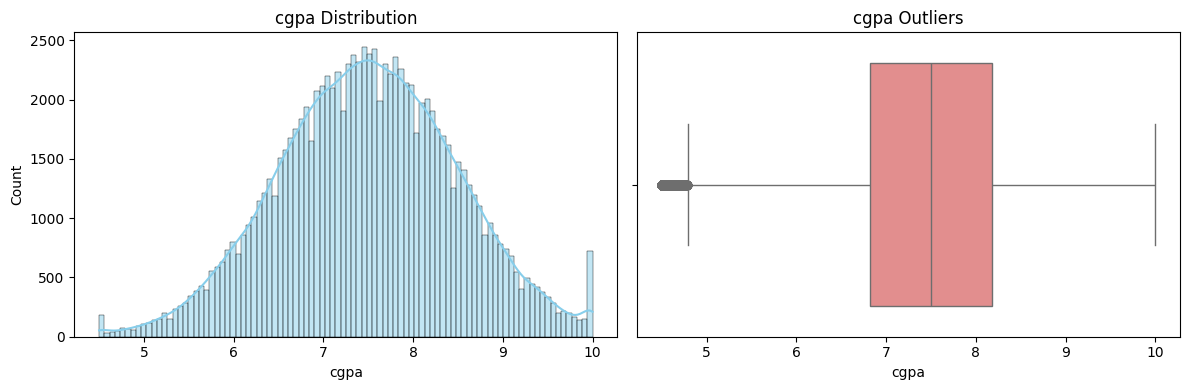

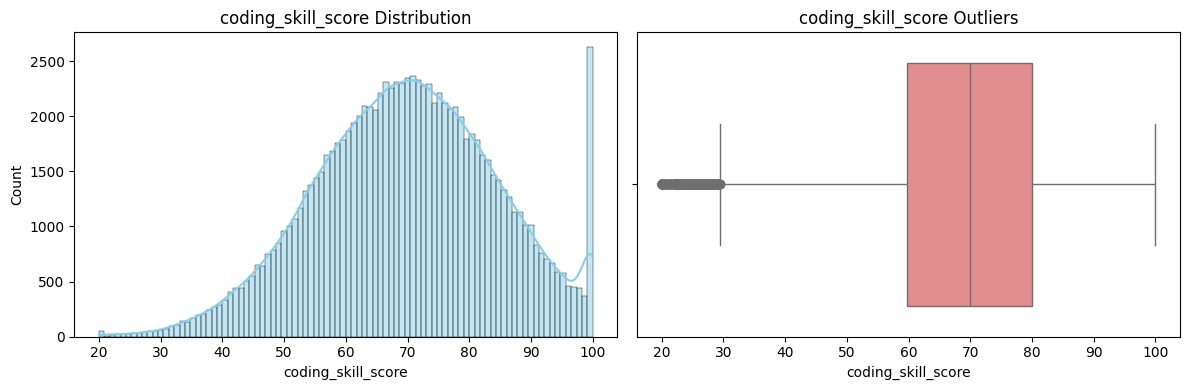

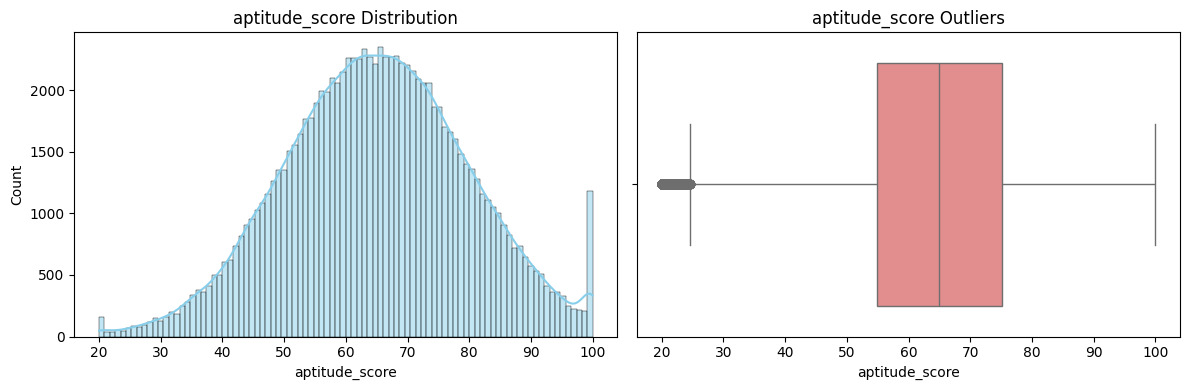

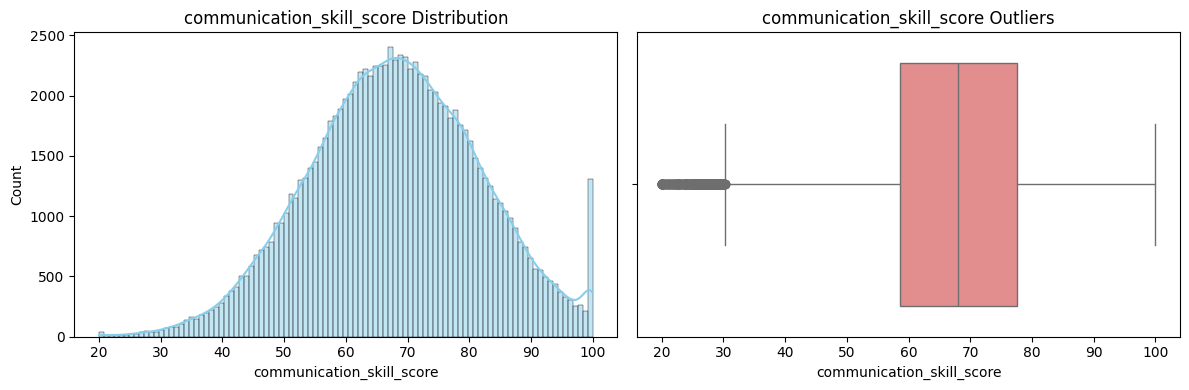

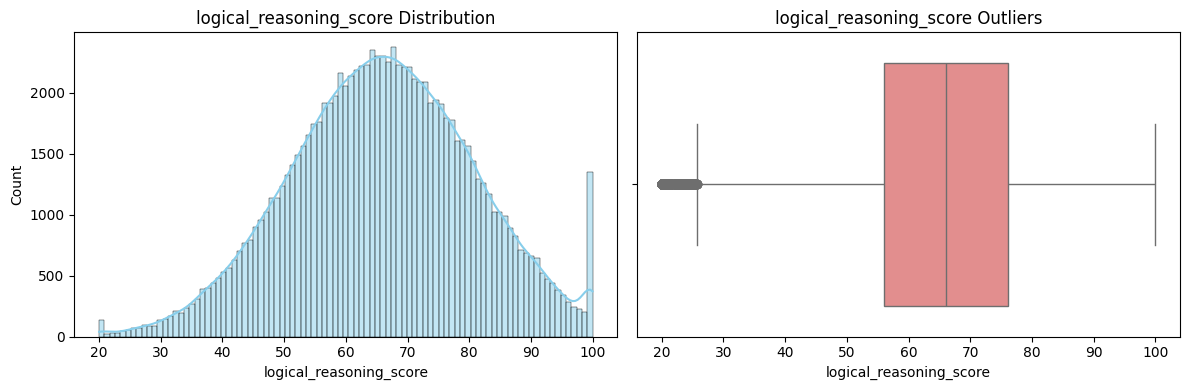

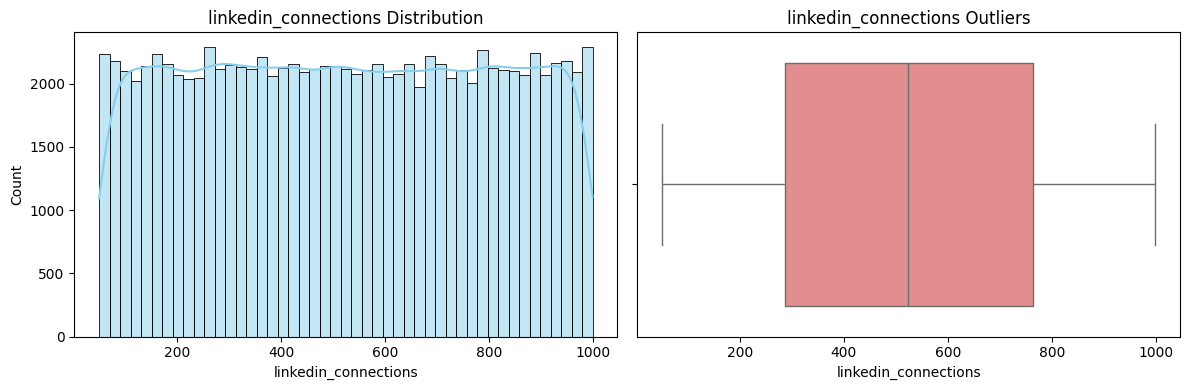

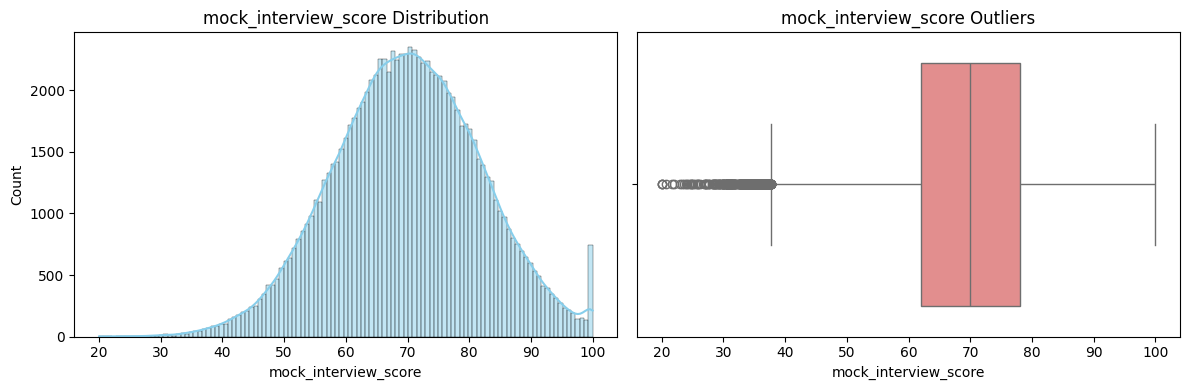

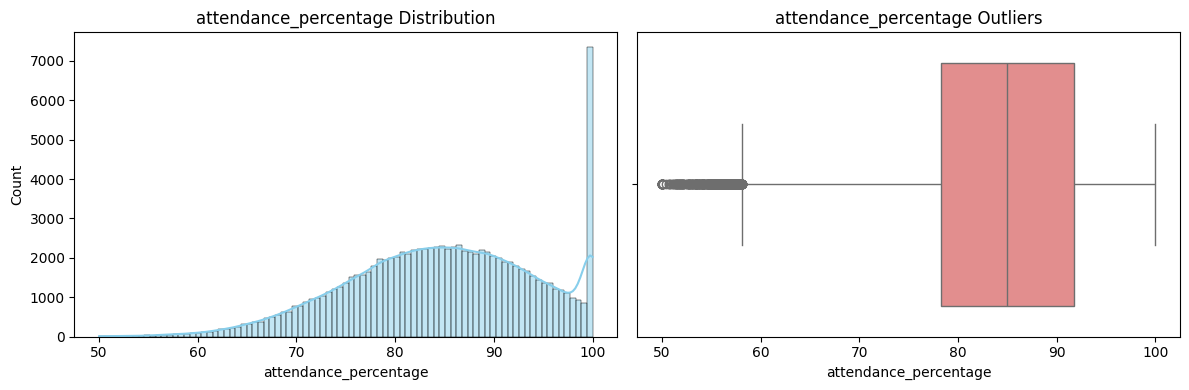

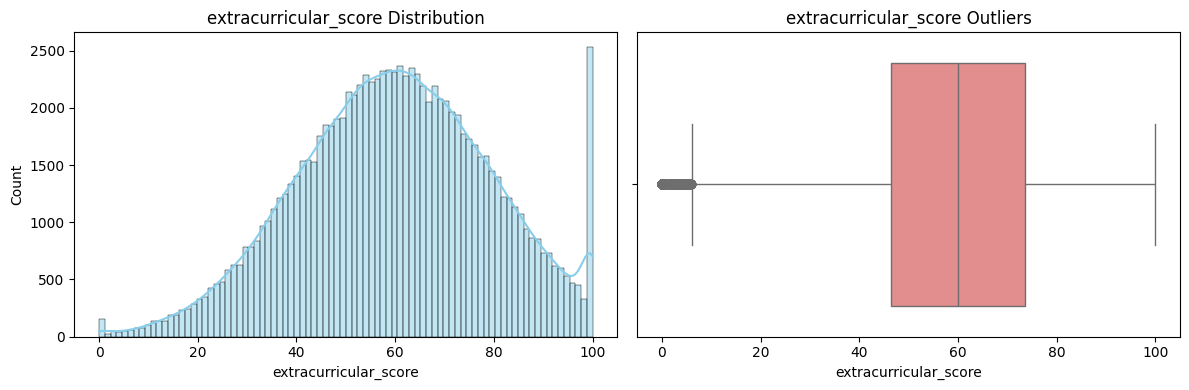

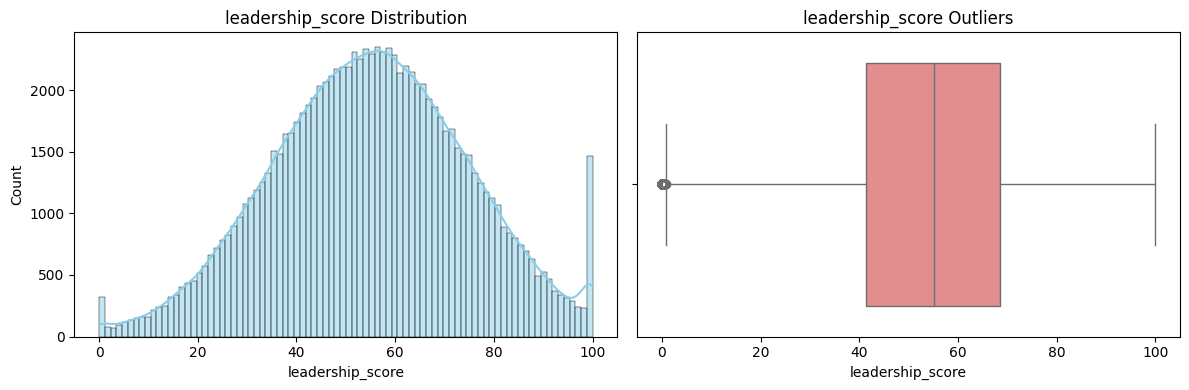

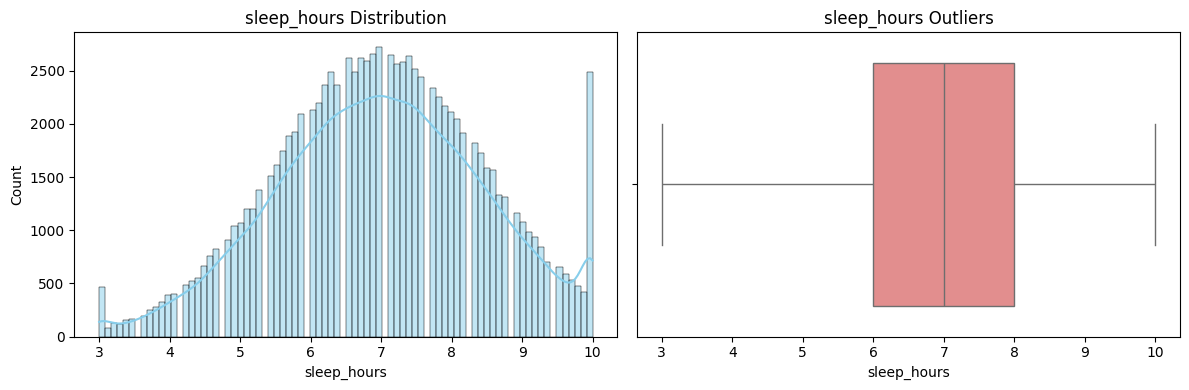

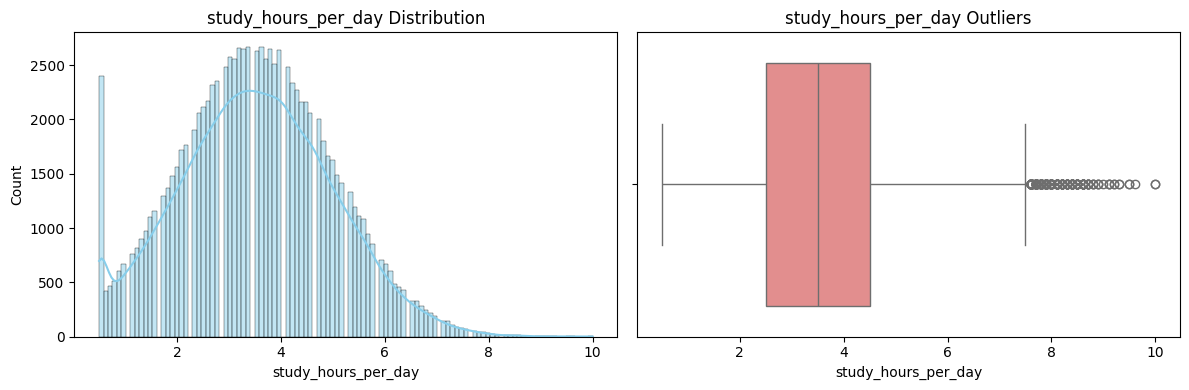

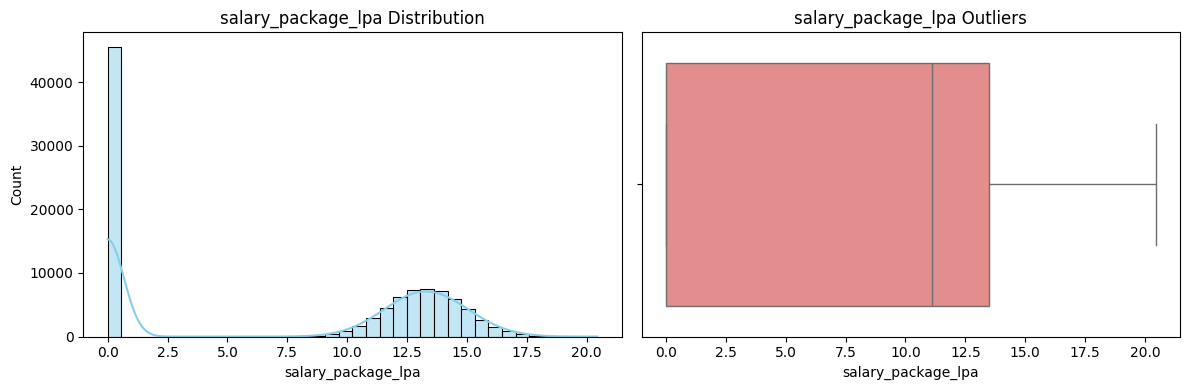

In [14]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

Above graphs shwos that majority of our data contains some outliers

### 3.1.2 Categorical Columns (Count plots)

In [15]:
import math

def count_plot(cols):
    n_cols = 2
    n_rows = math.ceil(len(cols) / n_cols)

    plt.figure(figsize=(16, 5 * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)

        sns.countplot(
            data=df,
            x=col,
            hue=col,
            order=df[col].value_counts().index,
            palette='viridis',
            legend=False
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


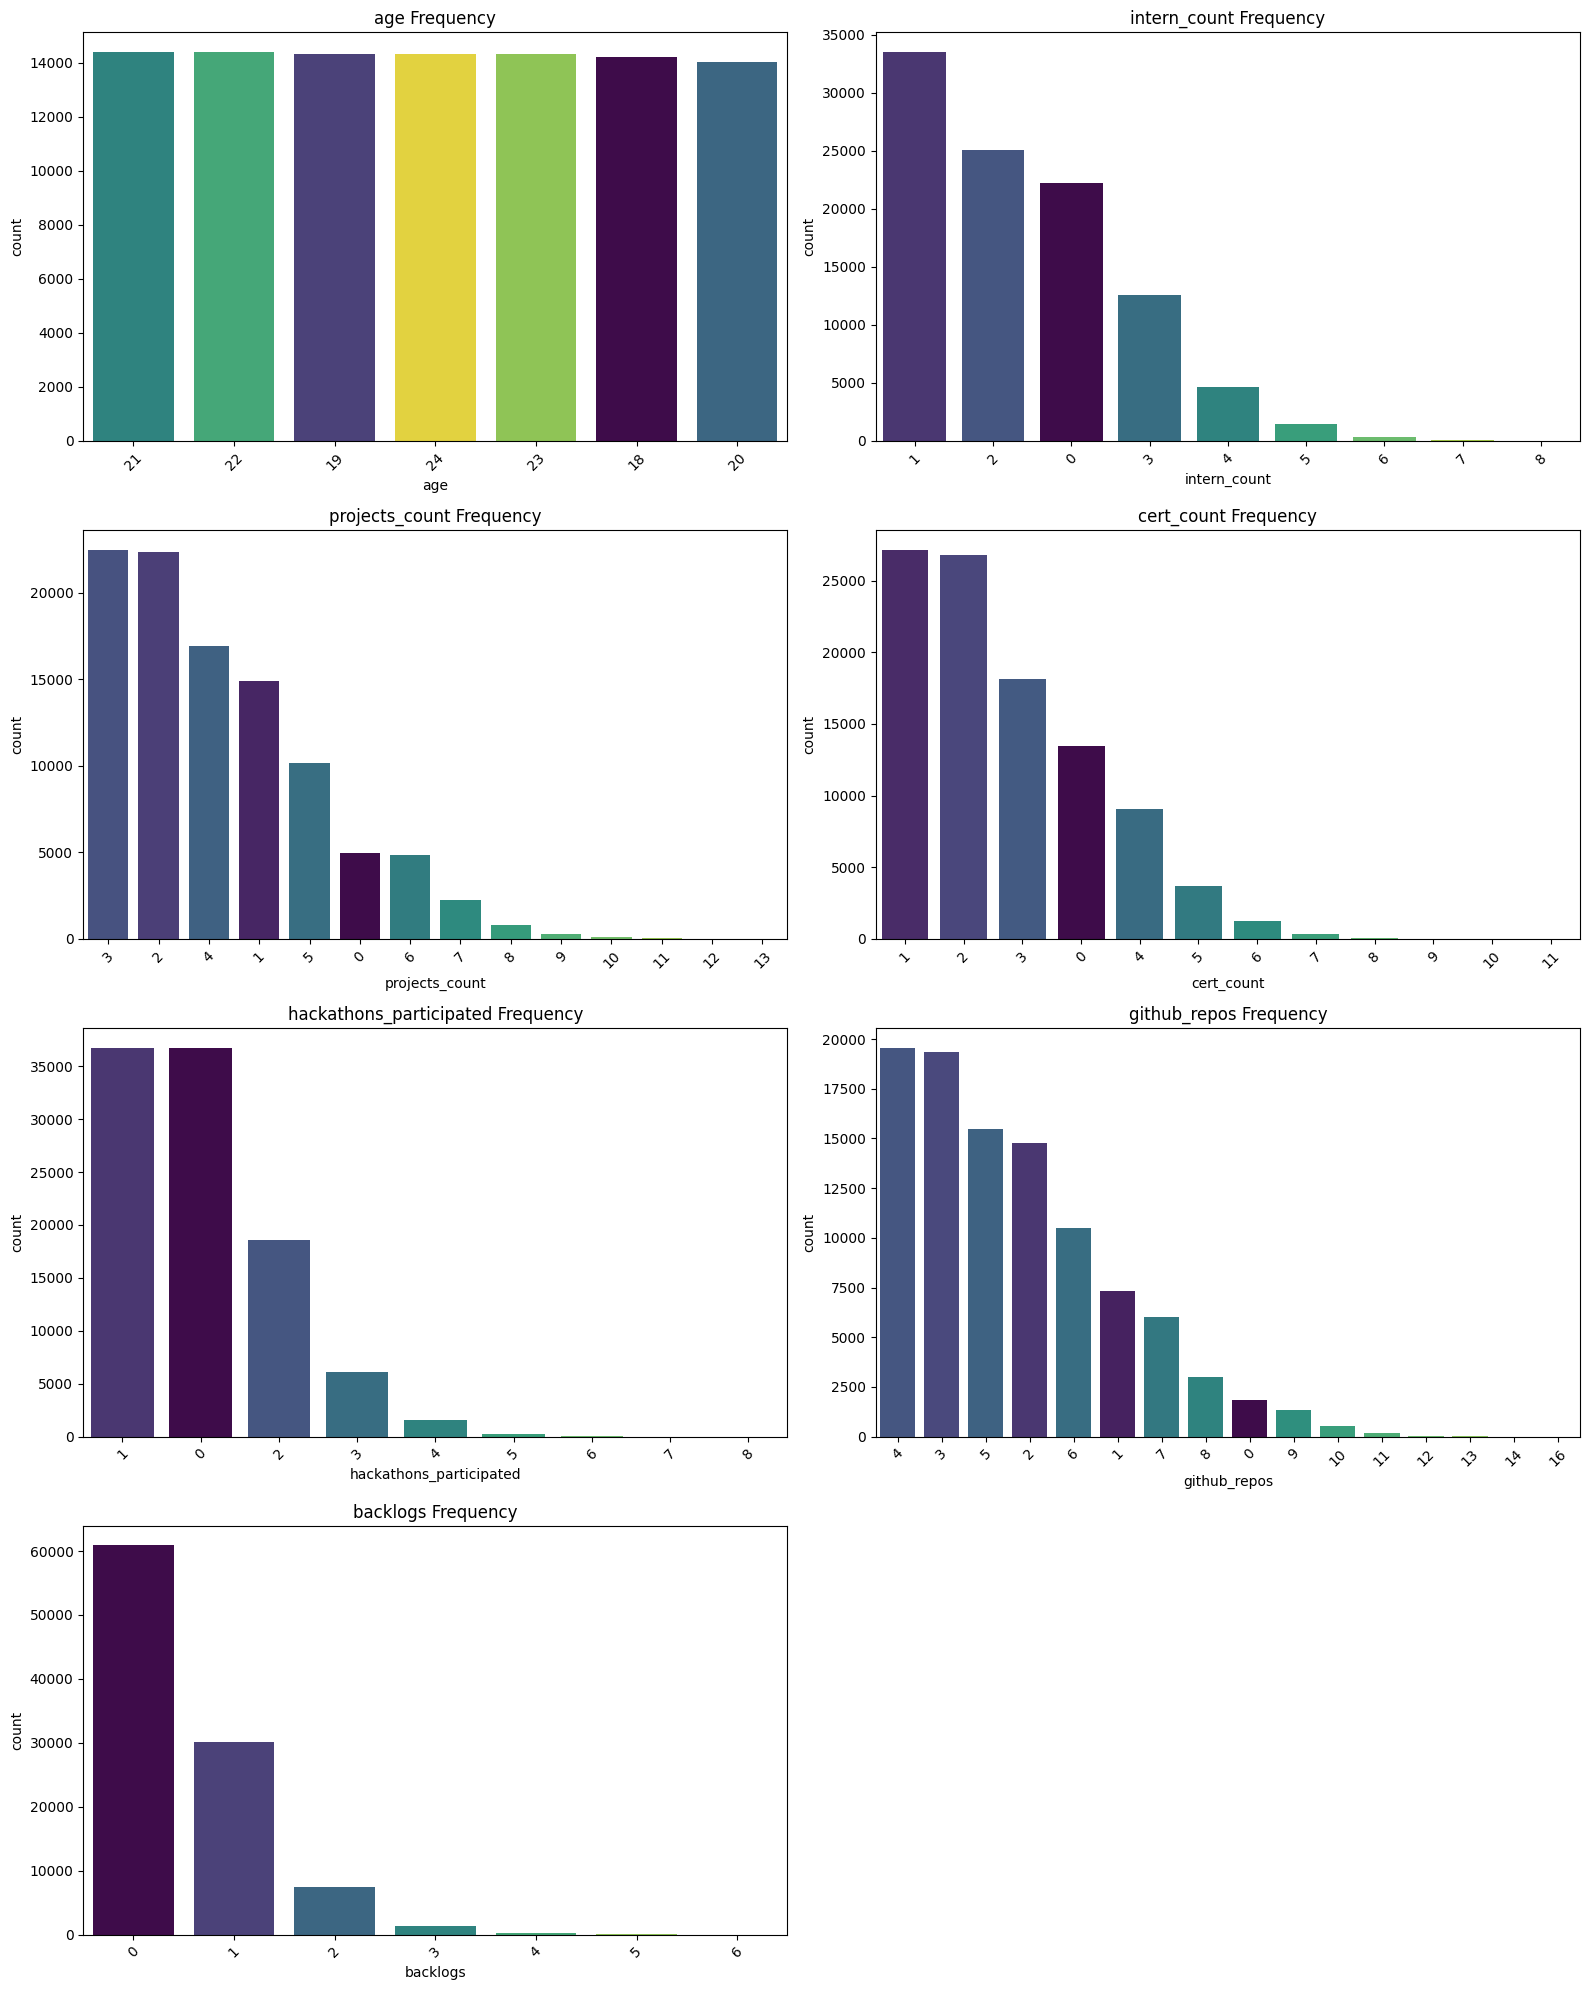

In [16]:
count_plot(num_cat_cols)

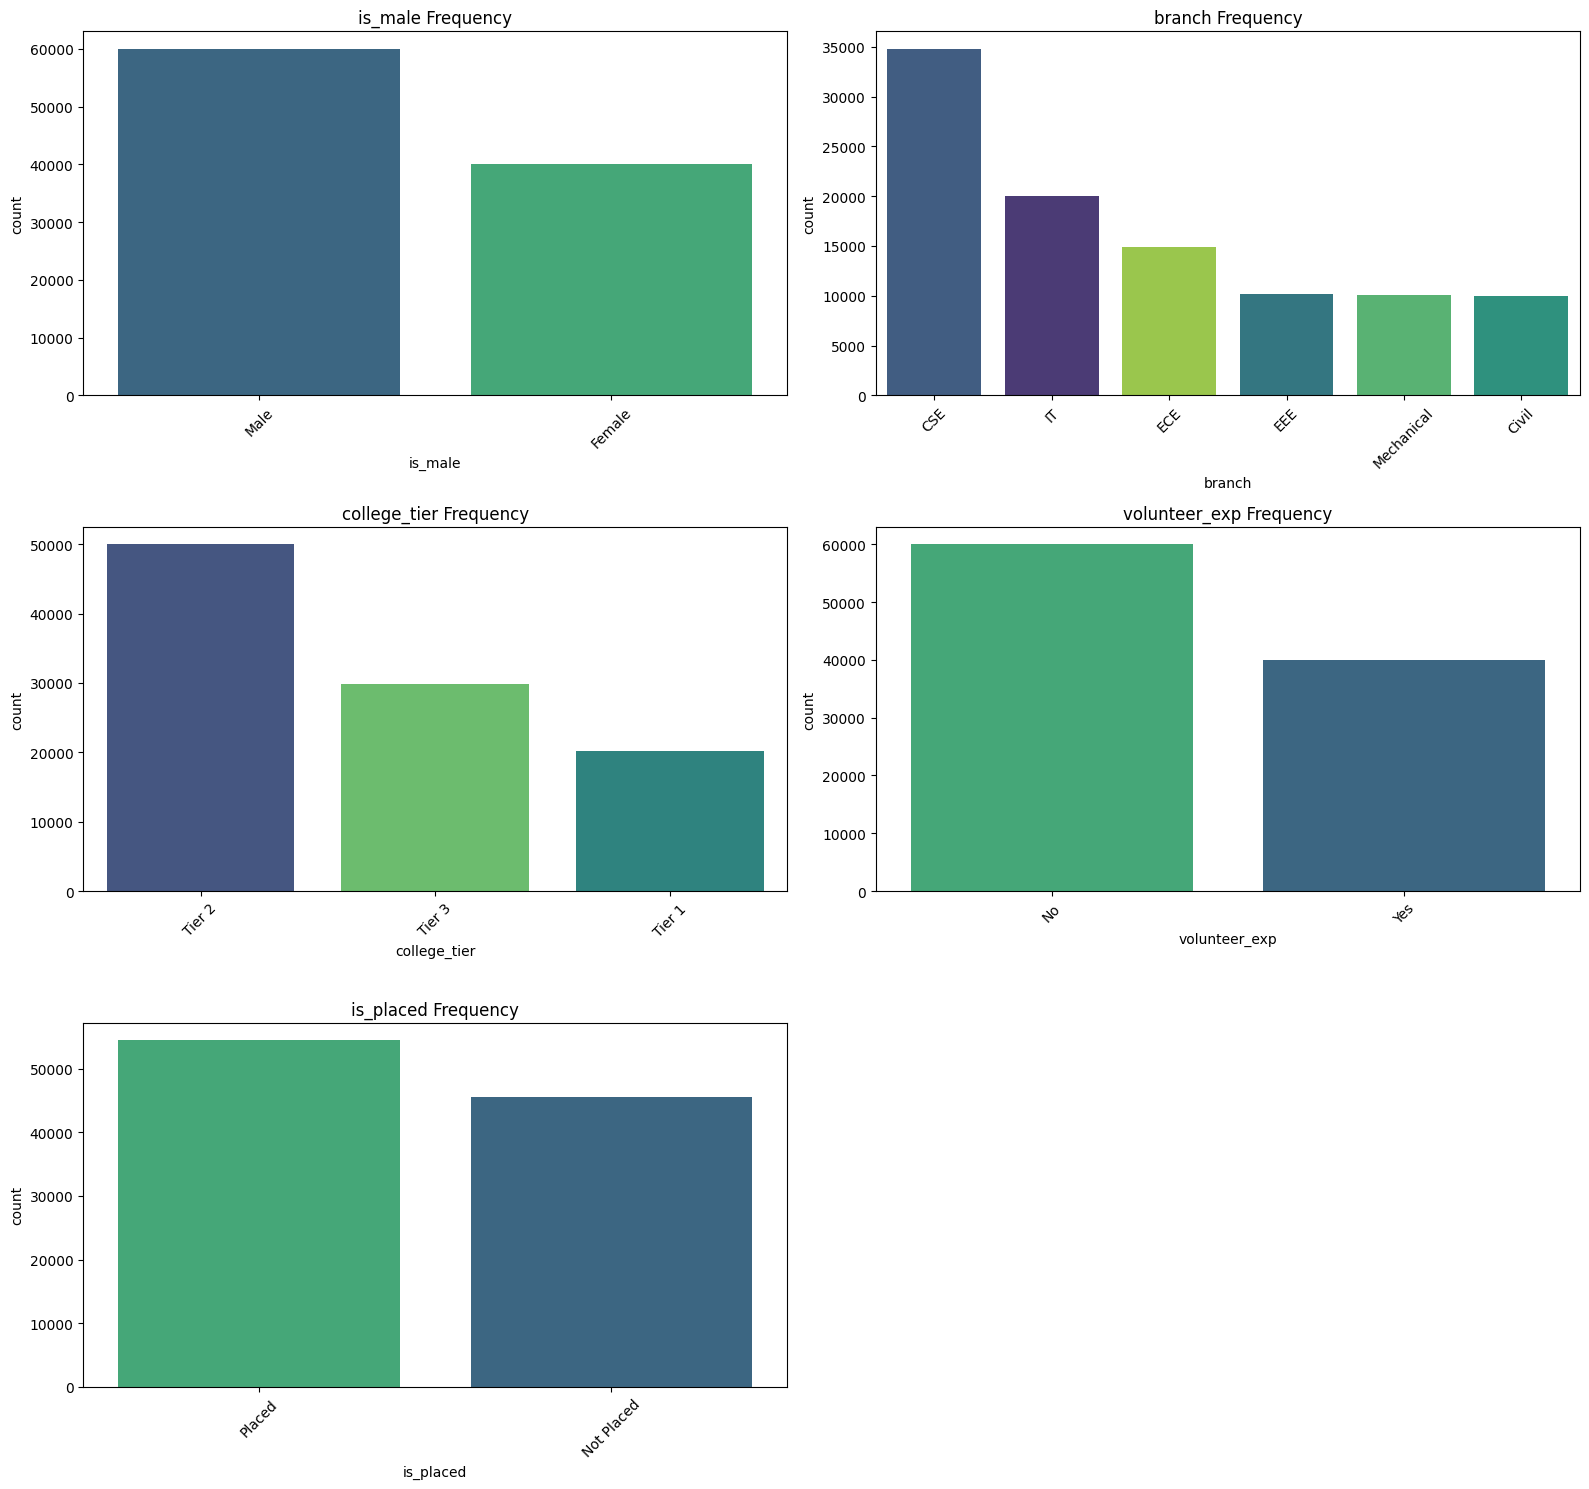

In [17]:
count_plot(cat_cols)

**With the help of above distribution we found**
* Males are more than females
* `CSE` branch has highest students
* Majority students are from `Tier 2` College
* More than `50%` of students are placed

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

In [18]:
num_pairs = [
    ('cgpa', 'salary_package_lpa'),
    ('coding_skill_score', 'mock_interview_score'),
    ('aptitude_score', 'logical_reasoning_score'),
    ('study_hours_per_day', 'cgpa'),
    ('attendance_percentage', 'cgpa')
]

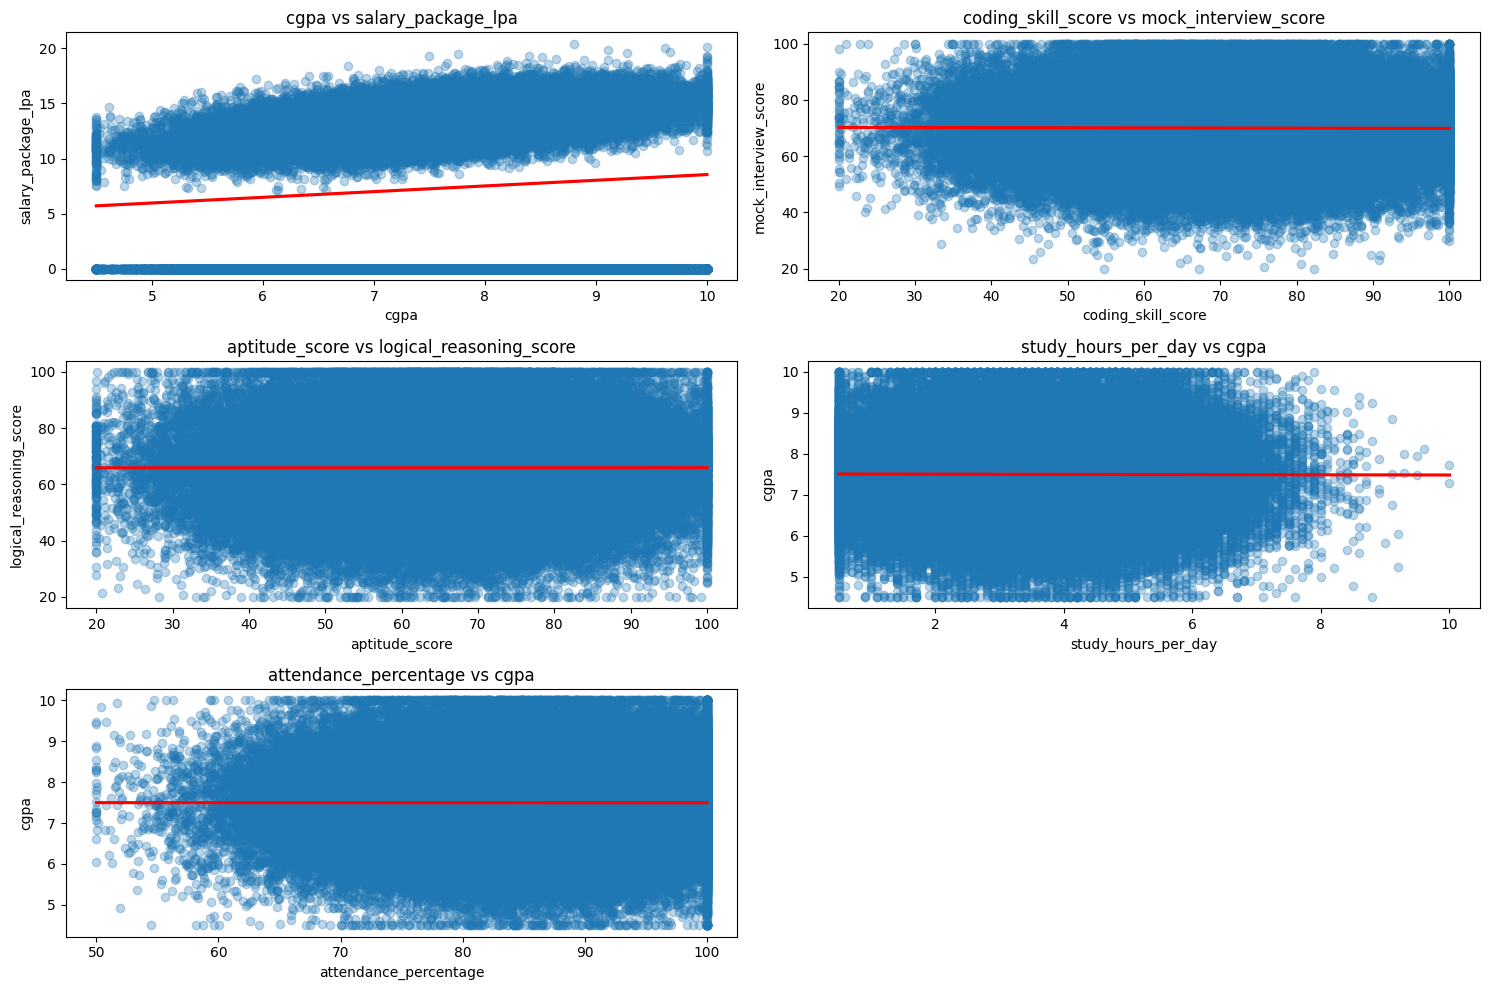

In [19]:
plt.figure(figsize=(15, 10))

for i, (x, y) in enumerate(num_pairs, 1):
    plt.subplot(3, 2, i)

    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )

    plt.title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

### 3.2.2 Categorical vs Categorical

In [20]:
cat_pairs = [
    ('is_male', 'is_placed'),
    ('branch', 'is_placed'),
    ('college_tier', 'is_placed'),
    ('volunteer_exp', 'is_placed')
]

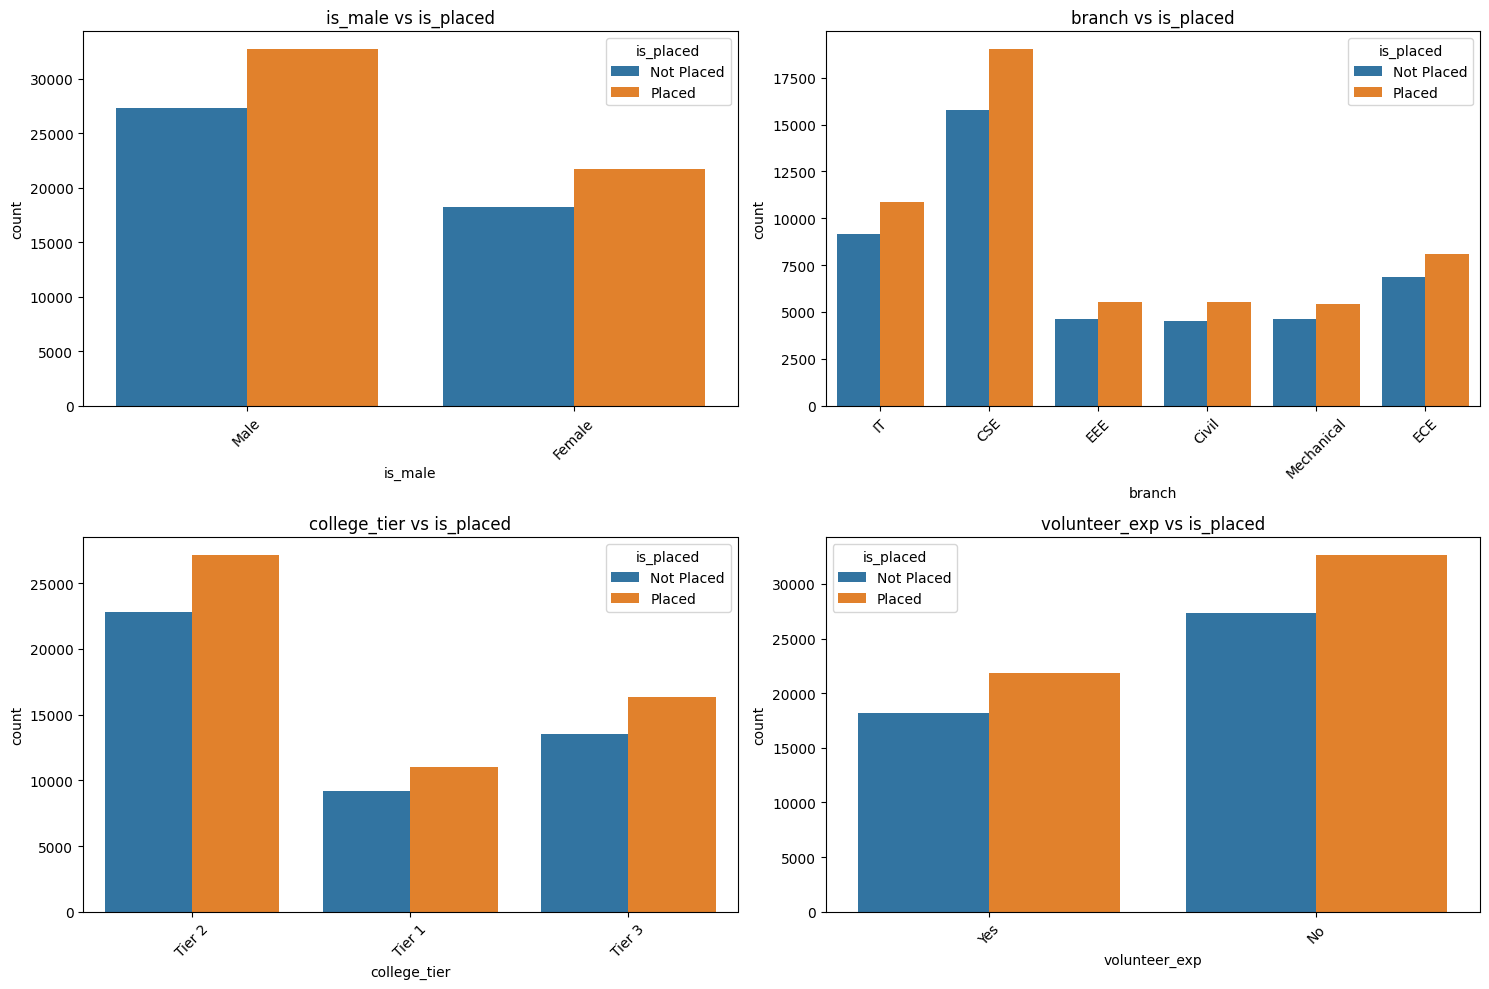

In [21]:
plt.figure(figsize=(15, 10))

for i, (x, y) in enumerate(cat_pairs, 1):
    plt.subplot(2, 2, i)

    sns.countplot(
        data=df,
        x=x,
        hue=y
    )

    plt.title(f'{x} vs {y}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.2.3 Numerical vs Categorical

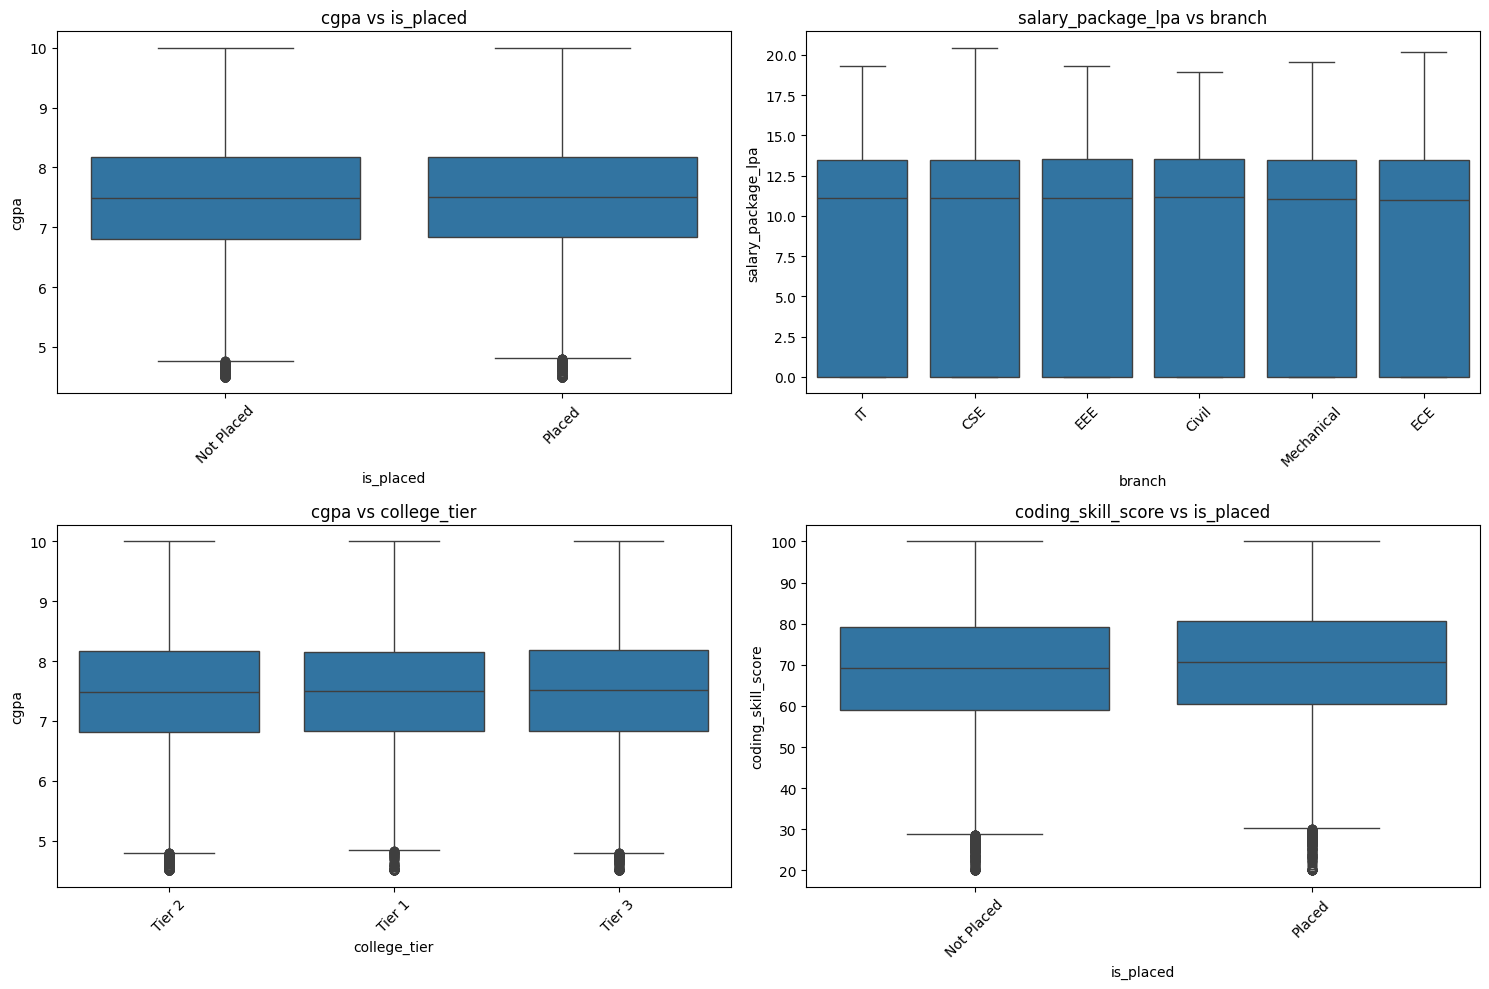

In [22]:
num_cat_pairs = [
    ('cgpa', 'is_placed'),
    ('salary_package_lpa', 'branch'),
    ('cgpa', 'college_tier'),
    ('coding_skill_score', 'is_placed')
]

plt.figure(figsize=(15, 10))

for i, (num, cat) in enumerate(num_cat_pairs, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x=cat,
        y=num
    )

    plt.title(f'{num} vs {cat}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.3 Multivariate Analysis

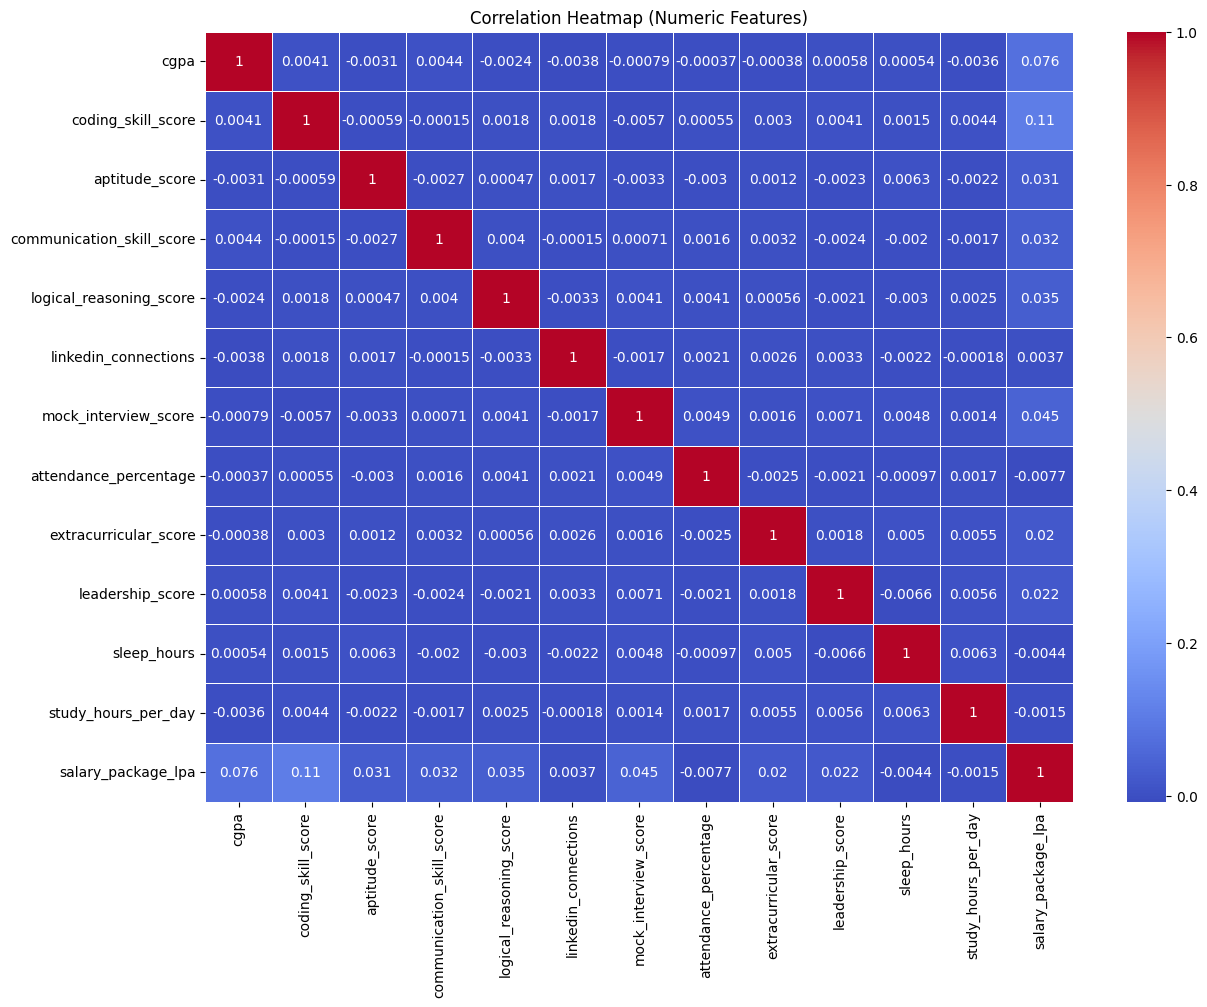

In [23]:
plt.figure(figsize=(14, 10))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [24]:
# Top Correlation Features
target = 'salary_package_lpa'

corr_target = df[num_cols].corr()[target].sort_values(ascending=False)

print(corr_target)

salary_package_lpa           1.000000
coding_skill_score           0.108336
cgpa                         0.076077
mock_interview_score         0.044840
logical_reasoning_score      0.035370
communication_skill_score    0.031718
aptitude_score               0.030821
leadership_score             0.021923
extracurricular_score        0.020219
linkedin_connections         0.003657
study_hours_per_day         -0.001530
sleep_hours                 -0.004402
attendance_percentage       -0.007694
Name: salary_package_lpa, dtype: float64


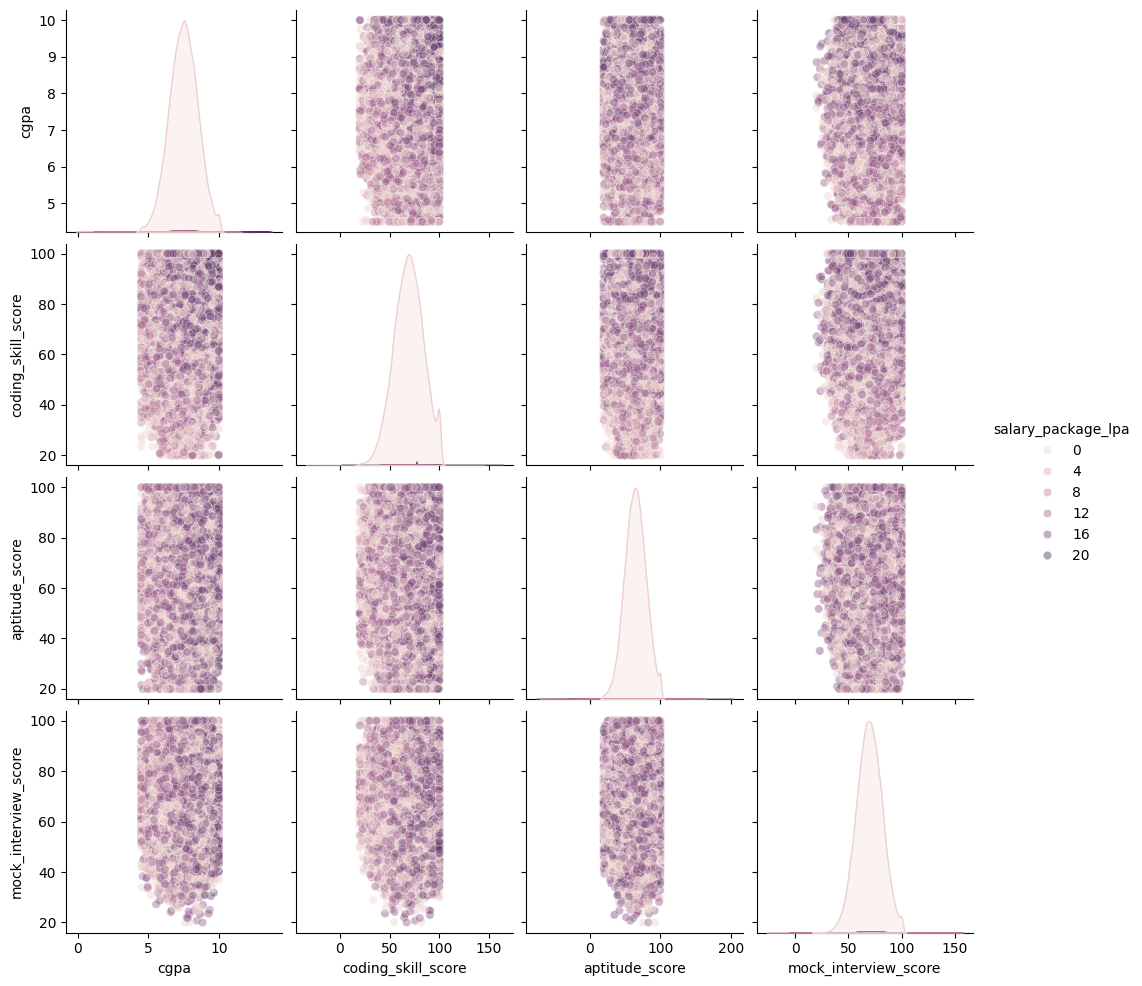

In [25]:
sns.pairplot(
    df,
    vars=['cgpa', 'coding_skill_score', 'aptitude_score', 'mock_interview_score'],
    hue='salary_package_lpa',
    plot_kws={'alpha': 0.4}
)

plt.show()

# 4. Feature Transformation

In [26]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [27]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

1449


## 4.1 One-Hot Encoding

In [28]:
df.shape

(100000, 25)

In [29]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(data=df,columns=cat_cols,drop_first = True,dtype=int)
df.head()

,age,cgpa,intern_count,projects_count,cert_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,...,is_male_Male,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical,college_tier_Tier 2,college_tier_Tier 3,volunteer_exp_Yes,is_placed_Placed
0,24,7.53,4,6,1,99.238568,81.707722,57.707166,59.070073,4,...,1,0,0,0,1,0,1,0,1,0
1,21,7.92,1,3,6,80.966123,63.116715,59.197085,78.976419,0,...,1,0,0,0,0,0,1,0,0,0
2,22,8.60,0,1,1,49.177184,48.658753,92.104885,80.603331,0,...,0,0,0,1,0,0,0,0,0,1
3,24,6.68,0,2,2,79.359084,66.376653,83.411798,64.187246,1,...,1,0,0,0,0,0,0,0,1,0
4,20,8.43,1,4,3,65.018573,61.274985,88.956331,56.163678,1,...,0,0,0,0,1,0,0,1,0,1


### Splitting Data before Feature scaling

In [30]:
X = df.drop('salary_package_lpa', axis=1)
y = df['salary_package_lpa']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 4.2 Standard Scaling

In [32]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [33]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,age,cgpa,intern_count,projects_count,cert_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,...,is_male_Male,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical,college_tier_Tier 2,college_tier_Tier 3,volunteer_exp_Yes,is_placed_Placed
75220,-1.003265,-0.531557,-1.224980,0.577060,-0.706989,0.220214,1.048606,1.835714,0.864301,-0.001427,...,0,0,0,0,0,0,0,1,1,0
48955,0.496421,-0.259380,2.857333,1.154720,-1.412276,0.146286,1.264906,1.039482,0.409210,0.999864,...,0,0,0,0,1,0,1,0,0,1
44966,-0.503370,-0.592040,0.407946,-0.000599,-0.706989,-0.273100,-0.776489,0.082310,0.397447,0.999864,...,1,0,1,0,0,0,1,0,1,0
13568,1.496211,-0.057768,0.407946,-0.000599,-1.412276,-0.420801,-0.617748,0.014962,0.580986,0.999864,...,1,0,0,0,0,0,1,0,1,1
92727,-1.503160,2.522867,-1.224980,1.154720,-0.001702,0.711256,-1.887657,0.920515,0.775359,-1.002718,...,0,0,1,0,0,0,0,0,1,1


# 5. Feature Engineering(using PCA)

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

In [35]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [36]:
print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 29
Reduced features: 22


In [37]:
print("Total variance retained:", sum(pca.explained_variance_ratio_))

Total variance retained: 0.9577751368021494


In [38]:
# Converting into DataFrame
X_train_pca = pd.DataFrame(X_train_pca)
X_test_pca = pd.DataFrame(X_test_pca)

# 6. Machine Learning with Hyperparameter Tuning

In [39]:
from sklearn.model_selection import RandomizedSearchCV,KFold
# Linear Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [40]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1  # if supported by your sklearn version
    ),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet": ElasticNet(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    # ============================
    # Boosting Models (CPU)
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',   # CPU-optimized
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        device='cpu',
        n_jobs=-1
    )
}

In [42]:
param_grids = {
    "Linear Regression": {},

    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10, 25, 50, 75,100]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 5, 7,10]
    },

    "ElasticNet": {
        "alpha": [0.001, 0.01, 0.1, 1, 5, 7,10],
        "l1_ratio": [0.2, 0.5, 0.8]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, 15],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1],
        "colsample_bytree": [0.7, 0.8, 1]
    },

    "LightGBM": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [31, 50, 100],
        "max_depth": [-1, 5, 10]
    }
}

In [43]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():

    print(f"\nRunning RandomizedSearchCV for {name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        cv=kf,
        scoring='r2',
        n_jobs=-1,
        n_iter = 6
    )

    random_search.fit(X_train_pca, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running RandomizedSearchCV for Linear Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=6. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression
Best Params: {}
Best CV Score (R2): 0.7984451046847653

Running RandomizedSearchCV for Ridge Regression...
Ridge Regression
Best Params: {'alpha': 1.0}
Best CV Score (R2): 0.7984451054141197

Running RandomizedSearchCV for Lasso Regression...
Lasso Regression
Best Params: {'alpha': 0.001}
Best CV Score (R2): 0.7984444834739098

Running RandomizedSearchCV for ElasticNet...
ElasticNet
Best Params: {'l1_ratio': 0.8, 'alpha': 0.001}
Best CV Score (R2): 0.7984437246659949

Running RandomizedSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 10}
Best CV Score (R2): 0.9785189297702217

Running RandomizedSearchCV for Random Forest...
Random Forest
Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}
Best CV Score (R2): 0.9847841360374554

Running RandomizedSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 64000, number of used features: 22
[LightGBM] [Info] Start training from score 7.256992
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 64000, number of used features: 22
[LightGBM] [Info] Start training from score 7.260715
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 64000, number of used features: 22
[LightGBM] [Info] Start tra

In [44]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
LightGBM,"{'num_leaves': 100, 'n_estimators': 500, 'max_...",0.986405
Random Forest,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.984784
XGBoost,"{'subsample': 0.7, 'n_estimators': 300, 'max_d...",0.979198
Decision Tree,"{'min_samples_split': 2, 'min_samples_leaf': 5...",0.978519
Ridge Regression,{'alpha': 1.0},0.798445
Linear Regression,{},0.798445
Lasso Regression,{'alpha': 0.001},0.798444
ElasticNet,"{'l1_ratio': 0.8, 'alpha': 0.001}",0.798444


In [45]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: LightGBM
Best CV Score (R2): 0.9864053154081105


In [46]:
y_pred = best_model.predict(X_test_pca)

In [47]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.49572875596168126
RMSE: 0.7989770607589535
R2 Score: 0.9858920953883082
